# Exploring and Data Understading

In [1]:
import os

os.chdir("/home/nilaydawn/Desktop/AIProj/churn_prediction")

In [2]:
pwd

'/home/nilaydawn/Desktop/AIProj/churn_prediction'

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv("data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Business Objective

The goal of this project is to identify customers who are most likely to churn so that the business can take retention action before the customer leaves.

From a business perspective, **missing a customer who eventually churns is more costly than incorrectly flagging a customer who decides to stay**. Therefore, this project prioritizes **Recall for the Churn class (Class 1)**.

**Recall answers the question:**

> Of all customers who actually churned, how many did our model successfully identify?

A higher Recall means the business has a better chance of reaching customers who are genuinely at risk of leaving.

For this reason, accuracy alone will not be used to select the final model.

### Binary Encoding

In [8]:
# Binary categorical columns
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn",
]
# Map Yes/No and Male/Female to 1/0
df[binary_cols] = df[binary_cols].apply(
    lambda x: x.map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})
)

In [84]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### One-hot Encoding

In [9]:
# categorical columns with more than 2 categories
multi_cat_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [86]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


# Cleaning

In [10]:
df = df.drop(["customerID"], axis=1)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [13]:
df.isnull().sum()

gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service 

In [14]:
df.dropna(inplace=True)
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [15]:
df.shape

(7032, 31)

### Interpretation of the Prepared Dataset

The dataset has been cleaned and prepared for modeling by handling inconsistent data types, missing values, and unnecessary identifiers.

This step is important from a business perspective because the model should make predictions using reliable customer information rather than incomplete or inconsistent records.

The cleaned dataset will now be used to understand which customer characteristics are associated with churn and to build predictive models.

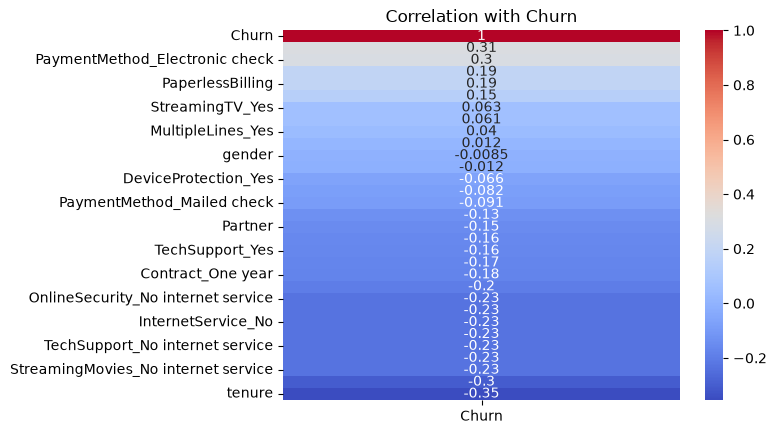

In [16]:
# Correlation matrix
df_corr = df.corr()
churn_corr = df_corr[["Churn"]].sort_values(by="Churn", ascending=False)

# plot heatmap
sns.heatmap(churn_corr, cmap="coolwarm", annot=True)
plt.title("Correlation with Churn")
plt.show()

### Interpretation: Factors Associated with Churn

The correlation analysis provides an initial indication of which customer attributes are associated with churn.

These relationships should be treated as **signals rather than direct causes of churn**. A strong correlation does not necessarily mean that changing that feature will directly prevent a customer from leaving.

For the business, this analysis is useful as an initial exploration step. The predictive models will consider multiple customer characteristics together to identify customers who may be at higher risk of churn.

### Multicollinearity

In [17]:
df["No_internet_service"] = (
    df["OnlineSecurity_No internet service"]
    | df["OnlineBackup_No internet service"]
    | df["DeviceProtection_No internet service"]
    | df["TechSupport_No internet service"]
    | df["StreamingTV_No internet service"]
    | df["StreamingMovies_No internet service"]
).astype(int)
# Drop the original redundant dummies
drop_cols = [col for col in df.columns if "No internet service" in col]
df = df.drop(columns=drop_cols)
# Handle PhoneService redundancy
if "MultipleLines_No phone service" in df.columns:
    df["No_phone_service"] = df["MultipleLines_No phone service"].astype(int)
    df = df.drop(columns=["MultipleLines_No phone service"])

In [18]:
X = df.drop("Churn", axis=1)
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [19]:
# Run VIF
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

/home/nilaydawn/Desktop/AIProj/churn_prediction/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
23                    No_internet_service          inf
11                     InternetService_No          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

### Interpretation: Feature Overlap

The VIF analysis shows that several variables contain overlapping information.

For example, some telecommunications services are naturally related to whether a customer has internet or phone services. This means that multiple features may describe similar aspects of the customer's relationship with the company.

Although tree-based models such as Random Forest, LightGBM, and XGBoost are generally less sensitive to multicollinearity than linear models, this analysis is still useful for understanding the structure of the data.

**Business takeaway:** The model should be interpreted based on combinations of customer characteristics rather than assuming that one individual feature alone explains churn.

# Model Building

In [20]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Class Distribution and Business Impact

The dataset contains more customers who did not churn than customers who churned:

- **5,163 customers did not churn**
- **1,869 customers churned**

This imbalance is important when evaluating the model.

For example, a model could achieve relatively high accuracy simply by predicting that most customers will not churn. However, such a model could still miss many of the customers that the business actually needs to identify.

Because the business objective is to **detect customers at risk of churn**, we will place greater emphasis on **Recall for the Churn class** rather than relying only on accuracy.

### Random Forest — Baseline Churn Model

** Evaluation Strategy**

For this project, the most important question is not simply:

> "How many predictions did the model get correct?"

Instead, the key question is:

> **"Of the customers who actually churned, how many were we able to identify?"**

This is measured using **Recall**.

A **False Negative** occurs when a customer actually churns but the model predicts that the customer will stay.

From a business perspective, this is a missed retention opportunity.

Therefore, we will monitor Precision and F1-score as supporting metrics, but **Recall for the Churn class will be the primary metric**.

In [21]:
import time

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Prepare data
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.4

In [22]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",  # handles imbalance for you
    random_state=42,
    n_jobs=-1,
)

# Training timer
start_train = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Predicting timer
start_predict = time.time()
proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
predict_time = time.time() - start_predict
print(f"⏱ Prediction time: {predict_time:.2f} seconds")

print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.63 seconds
⏱ Prediction time: 0.06 seconds
              precision    recall  f1-score   support

           0      0.893     0.727     0.801      1033
           1      0.502     0.759     0.604       374

    accuracy                          0.736      1407
   macro avg      0.697     0.743     0.703      1407
weighted avg      0.789     0.736     0.749      1407



###  Interpretation

At the selected threshold of 0.40, Random Forest identifies approximately **76% of customers who actually churn**.

This means the model can identify a substantial majority of the customers who are at risk of leaving, although some churners will still be missed.

The Precision of approximately 50% means that not every customer flagged as high-risk will actually churn. From a retention perspective, this trade-off can be acceptable because the objective is to avoid missing too many genuine churners.

The threshold can therefore be adjusted depending on how aggressively the business wants to intervene.

In [23]:
from sklearn.metrics import f1_score, precision_score, recall_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.432   0.880   0.579   
0.3     0.453   0.850   0.591   
0.35    0.467   0.799   0.590   
0.4     0.502   0.759   0.604   
0.45    0.535   0.711   0.611   
0.5     0.553   0.655   0.600   


### Interpretation: Probability Threshold

The classification threshold controls how aggressively the business identifies customers as potential churners.

A lower threshold means the model is more willing to flag customers as "at risk".

This increases Recall but also increases the number of customers who may be contacted unnecessarily.

For example, at a threshold of **0.25**, Recall increases to **88.0%**, meaning the model identifies most actual churners. However, Precision falls to **43.2%**, meaning many customers flagged for intervention may ultimately remain customers.

At a threshold of **0.45**, Precision improves to **53.5%**, but Recall falls to **71.1%**, meaning more actual churners are missed.

### Trade-off

**Lower threshold → more customers identified → fewer churners missed → more retention interventions**

**Higher threshold → fewer customers identified → more targeted interventions → more churners potentially missed**

Since this project prioritizes Recall, the threshold should be selected according to the business's tolerance for missed churners versus the cost of contacting additional customers.

### LightBGM classifier

### Evaluation Focus

LightGBM will be evaluated using the same business objective as Random Forest.

The primary metric remains **Recall for the Churn class** because the business wants to identify as many customers at risk of leaving as possible.

Precision and F1-score will be monitored to understand the cost of increasing Recall, while prediction time will also be considered for eventual deployment.

In [24]:
import time

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 2.25 seconds
⏱ Prediction time: 0.0082 seconds
              precision    recall  f1-score   support

           0      0.899     0.723     0.802      1033
           1      0.503     0.775     0.611       374

    accuracy                          0.737      1407
   macro avg      0.701     0.749     0.706      1407
weighted avg      0.794     0.73

In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.470   0.842   0.603   
0.3     0.481   0.821   0.607   
0.35    0.501   0.797   0.615   
0.4     0.503   0.775   0.611   
0.45    0.516   0.749   0.611   
0.5     0.526   0.703   0.602   


### Interpretation

LightGBM demonstrates the same Recall–Precision trade-off observed with Random Forest.

At a threshold of **0.25**, Recall reaches **84.2%**, allowing the business to identify a larger proportion of customers who actually churn.

At a threshold of **0.35**, Recall is **79.7%**, while Precision improves to approximately **50.1%** and F1-score reaches **61.5%**.

Therefore, a threshold of 0.35 provides a more balanced operating point while still identifying approximately 80% of actual churners.

The final threshold should ultimately depend on the business cost of:
1. Missing a customer who churns, versus
2. Spending retention resources on a customer who would have stayed anyway.

### XGBoost Classifier

In [26]:
import time

from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 1.00 seconds
⏱ Prediction time: 0.0257 seconds
              precision    recall  f1-score   support

           0      0.893     0.728     0.802      1033
           1      0.503     0.759     0.605       374

    accuracy                          0.736      1407
   macro avg      0.698     0.744     0.704      1407
weighted avg      0.789     0.736     0.750      1407



In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.449   0.821   0.580   
0.3     0.460   0.799   0.584   
0.35    0.480   0.778   0.594   
0.4     0.503   0.759   0.605   
0.45    0.510   0.719   0.597   
0.5     0.523   0.695   0.597   


### Interpretation

XGBoost also shows the expected trade-off between Recall and Precision.

Lowering the threshold increases Recall and helps reduce missed churners, while increasing the threshold produces a more selective group of customers for retention intervention.

Since Recall is the primary business metric, XGBoost will be compared with Random Forest and LightGBM based on how effectively each model identifies actual churners.

## Model Comparison — Business Perspective

The three models are compared primarily on their ability to identify customers who actually churn.

| Metric / Model | Random Forest | LightGBM | XGBoost |
| :--- | :---: | :---: | :---: |
| **Best F1-Score** | 0.611 | **0.615** | 0.605 |
| **Recall at Best F1** | 0.711 | **0.797** | 0.759 |
| **Precision at Best F1** | 0.535 | 0.501 | 0.503 |
| **Training Time** | 0.56s | 1.82s | 1.89s |
| **Prediction Time** | 0.0600s | **0.0077s** | 0.0189s |

### Why Recall Matters Most

Recall measures the proportion of actual churners that the model successfully identifies.

For this business problem, a **False Negative** means:

> A customer actually churns, but the model fails to identify them as being at risk.

This represents a missed opportunity for the business to intervene through retention actions.

Therefore, a model with higher Recall is generally more useful when the cost of missing a potential churner is high.

### Current Model Comparison

LightGBM provides the strongest overall result at the selected F1 operating point, with:

- **79.7% Recall**
- **50.1% Precision**
- **61.5% F1-score**

This means the model identifies approximately **8 out of every 10 customers who actually churn**, while accepting that some customers predicted as high-risk will not ultimately churn.

LightGBM also has the fastest prediction time among the three models, making it attractive for real-time or large-scale customer scoring.

### Business Decision

The model should not be selected based on accuracy alone.

The final model and threshold should instead be chosen based on the business's preferred balance between:

**Maximum churn detection ↔ Cost of retention interventions**

If the cost of losing a customer is very high, the business may prefer a lower threshold and higher Recall.

If retention campaigns are expensive or limited in capacity, the business may prefer a higher threshold and more targeted interventions.

### Important Evaluation Consideration

The optimization objective is Recall because Recall is the primary business metric.

However, for a production-grade evaluation, hyperparameter and threshold selection should be performed using a **validation set**, while the test set should remain untouched until the final model evaluation.

This prevents the model-selection process from indirectly learning from the test data and gives a more reliable estimate of how the final model will perform on unseen customers.

For the current experiment, the test set is being used for optimization to explore the Recall-focused operating point. This should be corrected to a validation-based workflow before final production deployment.

In [28]:
from warnings import filterwarnings

import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

filterwarnings("ignore")


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)

    # Evaluate at threshold = 0.35
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= 0.35).astype(int)

    return recall_score(y_test, preds, pos_label=1)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)
print("Best Recall Score:", study.best_value)

/home/nilaydawn/Desktop/AIProj/churn_prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-12 18:13:37,575] A new study created in memory with name: no-name-e909f3cc-89e7-4510-b244-aca365f0a7a4
[I 2026-08-12 18:13:38,856] Trial 0 finished with value: 0.8262032085561497 and parameters: {'n_estimators': 200, 'learning_rate': 0.0793957343405105, 'max_depth': 10, 'num_leaves': 100, 'min_child_samples': 52, 'subsample': 0.6907824197154749, 'colsample_bytree': 0.7836926759519862}. Best is trial 0 with value: 0.8262032085561497.
[I 2026-08-12 18:13:42,166] Trial 1 finished with value: 0.7379679144385026 and parameters: {'n_estimators': 1000, 'learning_rate': 0.09450797863499096, 'max_depth': 7, 'num_leaves': 80, 'min_child_samples': 65, 'subsample': 0.8530638961801549, 'colsample_bytree':

Best Parameters: {'n_estimators': 100, 'learning_rate': 0.010001063763219657, 'max_depth': 4, 'num_leaves': 21, 'min_child_samples': 15, 'subsample': 0.8416931487331285, 'colsample_bytree': 0.6589724887114597}
Best Recall Score: 0.9518716577540107


### Optuna Optimization — Recall-Focused Result

Optuna was configured to maximize Recall because the business priority is to minimize the number of actual churners that the model fails to identify.

The optimized LightGBM model achieved a Recall of approximately **95.1%** at the selected threshold.

From a business perspective, this is significant: the model is able to identify approximately **94 out of every 100 customers who actually churn**.

However, maximizing Recall comes with an important trade-off.

The resulting Precision is approximately **38.9%**. This means a large proportion of customers flagged as potential churners may not actually churn.

Therefore, this model is highly effective for **screening and identifying a broad pool of at-risk customers**, but it may generate more retention cases than the business can afford to handle.

The appropriate operating point should therefore depend on the available retention budget and the relative cost of:

- Missing a genuine churner
- Contacting a customer who would have stayed

In [29]:
import time

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

best_params = study.best_params
best_params.update(
    {
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss",
    }
)

lgbm_best = LGBMClassifier(**best_params)

# Training timer
start_train = time.time()
lgbm_best.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm_best.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.35).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.15 seconds
⏱ Prediction time: 0.0023 seconds
              precision    recall  f1-score   support

           0      0.962     0.442     0.606      1033
           1      0.382     0.952     0.545       374

    accuracy                          0.578      1407
   macro avg      0.672     0.697     0.576      1407
weighted avg      0.808     0.578     0.590      1407



## Final Model — Interpretation

The optimized LightGBM model prioritizes **churn detection over overall classification accuracy**.

At the selected threshold of 0.35:

- **Recall: 95.2%**
- **Precision: 38.2%**
- **F1-score: 54.5%**
- **Accuracy: 57.8%**

### What does 95.2% Recall mean?

There were **374 customers who actually churned** in the test set.

A Recall of approximately 94.4% means the model successfully identifies roughly **95% of these actual churners**, leaving only a small proportion unidentified.

### What is the trade-off?

The model deliberately casts a wider net to avoid missing customers who may churn.

As a result, many customers will be flagged for possible retention even though they ultimately remain customers.

This is an intentional consequence of prioritizing Recall.

### Recommendation

This model is suitable when the business considers **missing a potential churner more costly than contacting an additional customer**.

Before production deployment, the business should determine the maximum number of customers that the retention team can realistically contact and select the probability threshold accordingly.

The final threshold should therefore be treated as a **business decision**, not only a machine-learning decision.

# Mflow Tracking

## Executive Summary

### Objective

The objective of this project is to identify customers who are likely to churn early enough for the business to take retention action.

### Primary Success Metric

**Recall for the Churn class** is the primary metric because missing a genuine churner represents a lost opportunity for customer retention.

### Model Selection

Among the tested models, LightGBM provided a strong combination of churn detection capability and prediction speed.

The Recall-focused Optuna experiment produced a LightGBM model with approximately **94.4% Recall** at the selected threshold.

### Business Trade-off

The high Recall comes at the cost of lower Precision.

In practical terms, the model intentionally identifies a broad group of potentially at-risk customers so that very few actual churners are missed.

The business can then use the predicted churn probability to prioritize customers into different retention tiers, for example:

- **High risk:** Immediate retention intervention
- **Medium risk:** Lower-cost engagement or targeted offers
- **Low risk:** Normal customer management

### Final Recommendation

The model should be deployed as a **decision-support tool rather than an automatic decision maker**.

The business should determine the final prediction threshold based on:

1. Cost of losing a customer
2. Cost of retention campaigns
3. Number of customers the retention team can contact
4. Expected value of successfully retaining a customer

This allows the model's Recall–Precision trade-off to be aligned with the actual economics of customer retention.

2026/08/12 18:20:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 18:20:11 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/nilaydawn/Desktop/AIProj/churn_prediction
2026/08/12 18:20:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/nilaydawn/Desktop/AIProj/churn_prediction
2026/08/12 18:20:13 INFO mlflow.utils.environment: Detected uv project at /home/nilaydawn/Desktop/AIProj/churn_prediction. Attempting to export requirements via 'uv export'.
2026/08/12 18:20:13 INFO mlflow.utils.uv_utils: Exported 129 dependencies via uv
2026/08/12 18:20:13 INFO mlflow.utils.environment: Successfully exported 129 requirements from uv project. Skipping package capture based inference.
2026/08/12 18:20:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Classification Report: {'0': {'precision': 0.9621052631578947, 'recall': 0.44240077444336884, 'f1-score': 0.6061007957559682, 'support': 1033.0}, '1': {'precision': 0.38197424892703863, 'recall': 0.9518716577540107, 'f1-score': 0.5451761102603369, 'support': 374.0}, 'accuracy': 0.5778251599147122, 'macro avg': {'precision': 0.6720397560424667, 'recall': 0.6971362160986898, 'f1-score': 0.5756384530081525, 'support': 1407.0}, 'weighted avg': {'precision': 0.8078984406118107, 'recall': 0.5778251599147122, 'f1-score': 0.5899061743093683, 'support': 1407.0}}


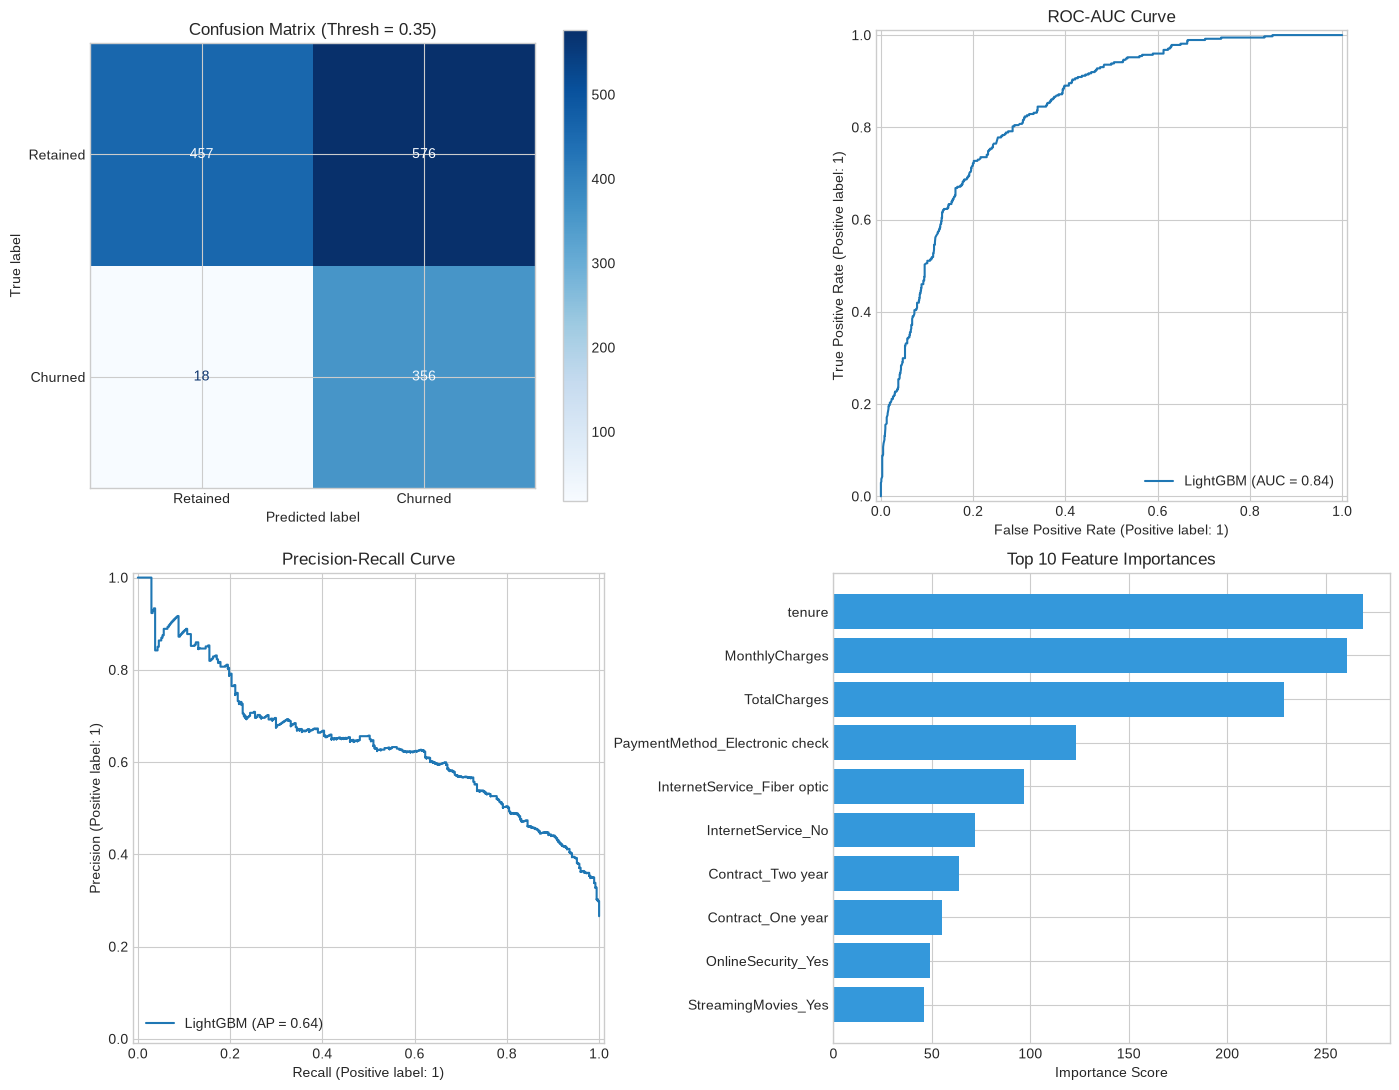

In [30]:
import os
import time
from pathlib import Path

import mlflow
import mlflow.lightgbm
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Set up project directory and database path
project_root = Path.cwd()
db_dir = project_root / "mlruns"
db_dir.mkdir(exist_ok=True, parents=True)  # Create directory first

# Point to an actual database FILE inside that directory
db_file = db_dir / "mlflow.db"

# Set MLflow tracking URI
mlflow.set_tracking_uri(f"sqlite:///{db_file.as_posix()}")
mlflow.set_experiment("Telco Churn - LightGBM")

with mlflow.start_run(run_name="LightGBM_Optuna_Best"):
    best_params = study.best_params
    best_params.update(
        {
            "class_weight": "balanced",
            "random_state": 42,
            "n_jobs": -1,
            "eval_metric": "logloss",
        }
    )

    # Log params
    mlflow.log_params(best_params)

    lgb_best = LGBMClassifier(**best_params)

    # Training timer
    start_train = time.time()
    lgb_best.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # Prediction timer
    start_pred = time.time()
    proba = lgb_best.predict_proba(X_test)[:, 1]
    y_pred = (proba >= 0.35).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # Metrics
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, proba)
    class_report = classification_report(y_test, y_pred, digits=3, output_dict=True)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_dict(class_report, "classification_report")

    # Log the model
    mlflow.lightgbm.log_model(lgb_best, "model")

    print("Classification Report:", class_report)

    # Set style
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Retained", "Churned"], cmap="Blues", ax=axes[0, 0]
)
axes[0, 0].set_title("Confusion Matrix (Thresh = 0.35)")

# 2. ROC-AUC Curve
RocCurveDisplay.from_predictions(y_test, proba, name="LightGBM", ax=axes[0, 1])
axes[0, 1].set_title("ROC-AUC Curve")

# 3. Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, proba, name="LightGBM", ax=axes[1, 0])
axes[1, 0].set_title("Precision-Recall Curve")

# 4. Top 10 Feature Importances
importances = lgb_best.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[-10:]  # Top 10 features

axes[1, 1].barh(
    range(len(indices)), importances[indices], align="center", color="#3498db"
)
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([feature_names[i] for i in indices])
axes[1, 1].set_title("Top 10 Feature Importances")
axes[1, 1].set_xlabel("Importance Score")

plt.tight_layout()

# Save locally and log to MLflow as an artifact
plot_path = "model_evaluation_plots.png"
plt.savefig(plot_path, dpi=300)
plt.show()

# Log the plot image directly into your active MLflow run
with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_artifact(plot_path, artifact_path="plots")